In [41]:
import numpy as np
import pandas as pd
import os
import datetime as dt
import time
from copy import deepcopy
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

In [43]:
df1 = pd.read_csv('train_results_final1.csv')
df2 = pd.read_csv('train_results_final3.csv')
df2['iteration'] = df2['iteration'] + 200
df = pd.concat([df1, df2], ignore_index=True)

In [45]:
val_res = df[['iteration', 'new_train_log_loss', 'new_validation_log_loss']]
initial_res = df[['iteration', 'pre_train_log_loss', 'pre_validation_log_loss']].iloc[:1]
initial_res = initial_res.rename(columns={'pre_train_log_loss': 'new_train_log_loss', 'pre_validation_log_loss': 'new_validation_log_loss'})
initial_res['iteration'] = 0

full_res = pd.concat([initial_res, val_res], ignore_index=True)

In [47]:
full_res.head(20)

,iteration,new_train_log_loss,new_validation_log_loss
0,0,0.624430,0.457798
1,1,0.593950,0.449153
2,2,0.572630,0.444860
3,3,0.561233,0.444791
4,4,0.556617,0.447983
5,5,0.555630,0.450163
6,6,0.555074,0.449362
7,7,0.554627,0.449290
8,8,0.554219,0.448896
9,9,0.553837,0.448539


In [49]:
cons_incr = 0
prev_x = 100
for i, x in zip(full_res['iteration'], full_res['new_validation_log_loss']):
    if x > prev_x:
        cons_incr += 1

    else:
        cons_incr = 0

    prev_x = x

    print(f'Iteration {i}: {cons_incr}')

Iteration 0: 0
Iteration 1: 0
Iteration 2: 0
Iteration 3: 0
Iteration 4: 1
Iteration 5: 2
Iteration 6: 0
Iteration 7: 0
Iteration 8: 0
Iteration 9: 0
Iteration 10: 0
Iteration 11: 0
Iteration 12: 0
Iteration 13: 0
Iteration 14: 0
Iteration 15: 0
Iteration 16: 0
Iteration 17: 0
Iteration 18: 0
Iteration 19: 0
Iteration 20: 0
Iteration 21: 0
Iteration 22: 0
Iteration 23: 0
Iteration 24: 0
Iteration 25: 0
Iteration 26: 0
Iteration 27: 0
Iteration 28: 0
Iteration 29: 0
Iteration 30: 0
Iteration 31: 0
Iteration 32: 0
Iteration 33: 0
Iteration 34: 0
Iteration 35: 0
Iteration 36: 0
Iteration 37: 0
Iteration 38: 0
Iteration 39: 0
Iteration 40: 0
Iteration 41: 0
Iteration 42: 0
Iteration 43: 0
Iteration 44: 0
Iteration 45: 0
Iteration 46: 0
Iteration 47: 0
Iteration 48: 0
Iteration 49: 0
Iteration 50: 0
Iteration 51: 0
Iteration 52: 0
Iteration 53: 0
Iteration 54: 0
Iteration 55: 0
Iteration 56: 0
Iteration 57: 0
Iteration 58: 0
Iteration 59: 0
Iteration 60: 0
Iteration 61: 0
Iteration 62: 0
It

In [51]:
df.loc[(df['iteration'] > 214) & (df['iteration'] < 224)]

,iteration,elo_game_value,num_rounds_degree,num_drivers_degree,default_rating,new_agent_alpha,pre_train_log_loss,pre_validation_log_loss,elo_game_value_delta,new_elo_game_value,num_rounds_degree_delta,new_num_rounds_degree,num_drivers_degree_delta,new_num_drivers_degree,default_rating_delta,new_default_rating,new_agent_alpha_delta,new_new_agent_alpha,new_train_log_loss,new_validation_log_loss
214,215,96.165597,0.159392,0.616838,1834.592719,0.770130,0.545494,0.441195,0.031176,96.196773,-0.000464,0.158928,0.000531,0.617369,0.009082,1834.601801,-0.001724,0.768406,0.545492,0.441195
215,216,96.196773,0.158928,0.617369,1834.601801,0.768406,0.545492,0.441195,0.031171,96.227944,-0.000461,0.158467,0.000529,0.617899,0.009003,1834.610803,-0.001707,0.766699,0.545490,0.441195
216,217,96.227944,0.158467,0.617899,1834.610803,0.766699,0.545490,0.441195,0.031165,96.259109,-0.000459,0.158008,0.000527,0.618426,0.008924,1834.619728,-0.001690,0.765009,0.545488,0.441195
217,218,96.259109,0.158008,0.618426,1834.619728,0.765009,0.545488,0.441195,0.031159,96.290267,-0.000456,0.157552,0.000526,0.618952,0.008847,1834.628575,-0.001674,0.763335,0.545487,0.441195
218,219,96.290267,0.157552,0.618952,1834.628575,0.763335,0.545487,0.441195,0.031153,96.321420,-0.000454,0.157099,0.000524,0.619475,0.008771,1834.637345,-0.001657,0.761678,0.545485,0.441195
219,220,96.321420,0.157099,0.619475,1834.637345,0.761678,0.545485,0.441195,0.031147,96.352567,-0.000451,0.156648,0.000522,0.619997,0.008695,1834.646040,-0.001641,0.760036,0.545483,0.441195
220,221,96.352567,0.156648,0.619997,1834.646040,0.760036,0.545483,0.441195,0.031140,96.383707,-0.000449,0.156199,0.000520,0.620517,0.008620,1834.654661,-0.001625,0.758411,0.545481,0.441195
221,222,96.383707,0.156199,0.620517,1834.654661,0.758411,0.545481,0.441195,0.031134,96.414841,-0.000446,0.155753,0.000518,0.621035,0.008547,1834.663207,-0.001610,0.756801,0.545479,0.441195
222,223,96.414841,0.155753,0.621035,1834.663207,0.756801,0.545479,0.441195,0.031127,96.445968,-0.000444,0.155309,0.000516,0.621551,0.008474,1834.671681,-0.001594,0.755207,0.545477,0.441195


In [55]:
titles = {
    'new_train_log_loss': 'Log loss value per iteration for a train dataset',
    'new_validation_log_loss': 'Log loss value per iteration for a validation dataset',
}

col_name_mapping = {
    'elo_game_value': 'Elo game adjustment value',
    'num_rounds_degree': 'Degree for number of rounds adjustment for related season',
    'num_drivers_degree': 'Degree for number of drivers adjustment for related round',
    'default_rating': 'Initial rating for a new driver',
    'new_agent_alpha': 'Coefficient of new driver rating update increment',
}

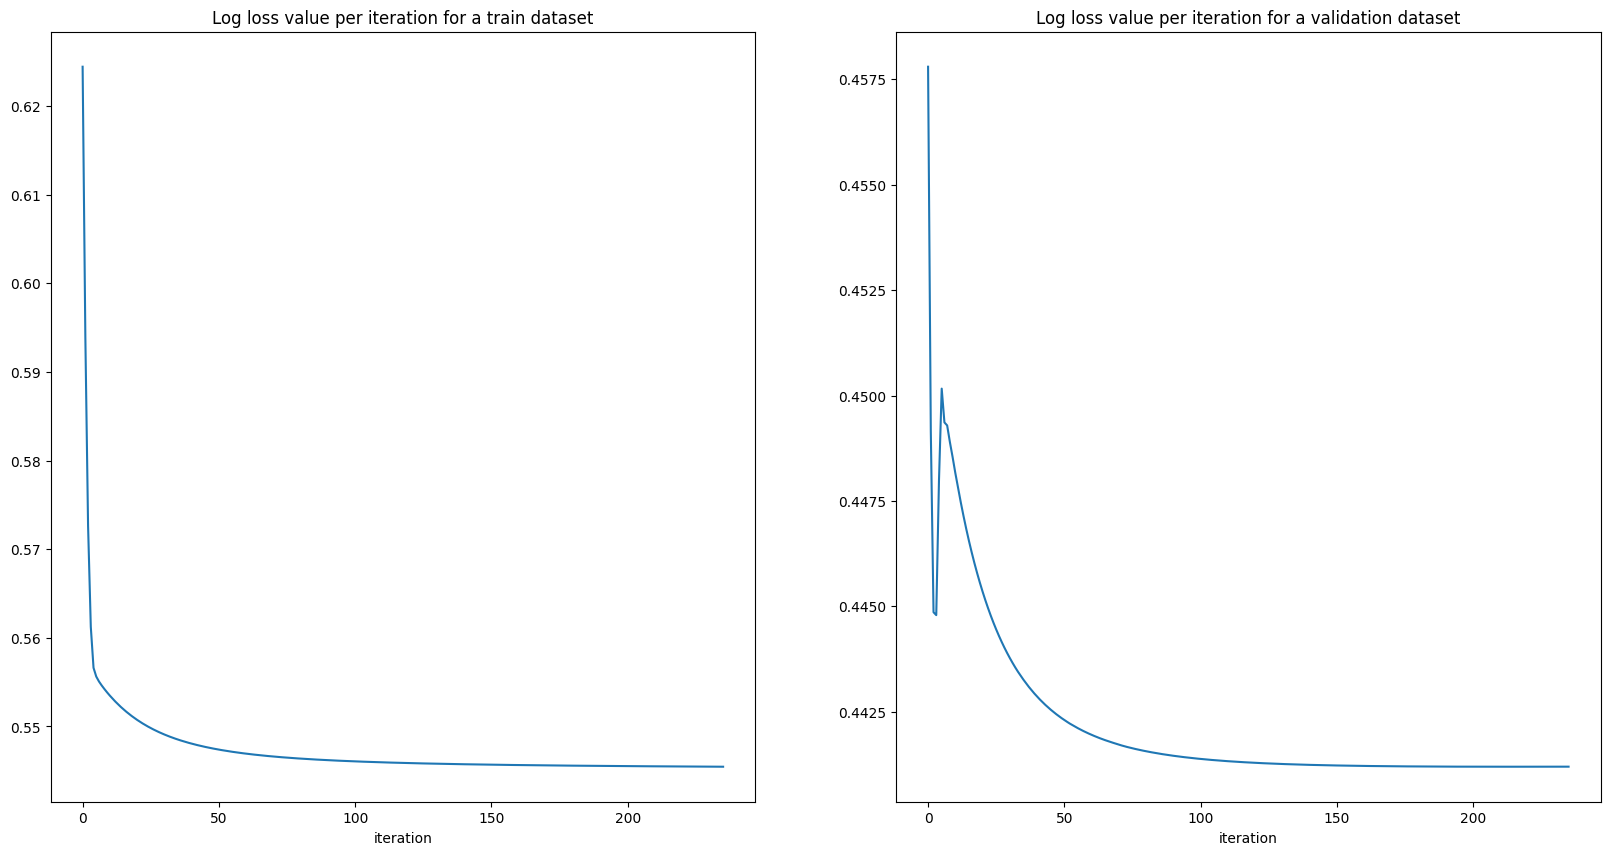

In [57]:
fig, axs = plt.subplots(ncols=2, nrows=1, figsize=(20, 10))
index = 0
axs = axs.flatten()
for col in ['new_train_log_loss', 'new_validation_log_loss']:
    axs[index].plot(full_res['iteration'], full_res[col])
    axs[index].set_xlabel('iteration')
    axs[index].set_ylabel(col_name_mapping.get(col))
    axs[index].set_title(titles.get(col))
    index += 1
# plt.tight_layout(pad=0.5, w_pad=0.5, h_pad=5.0)

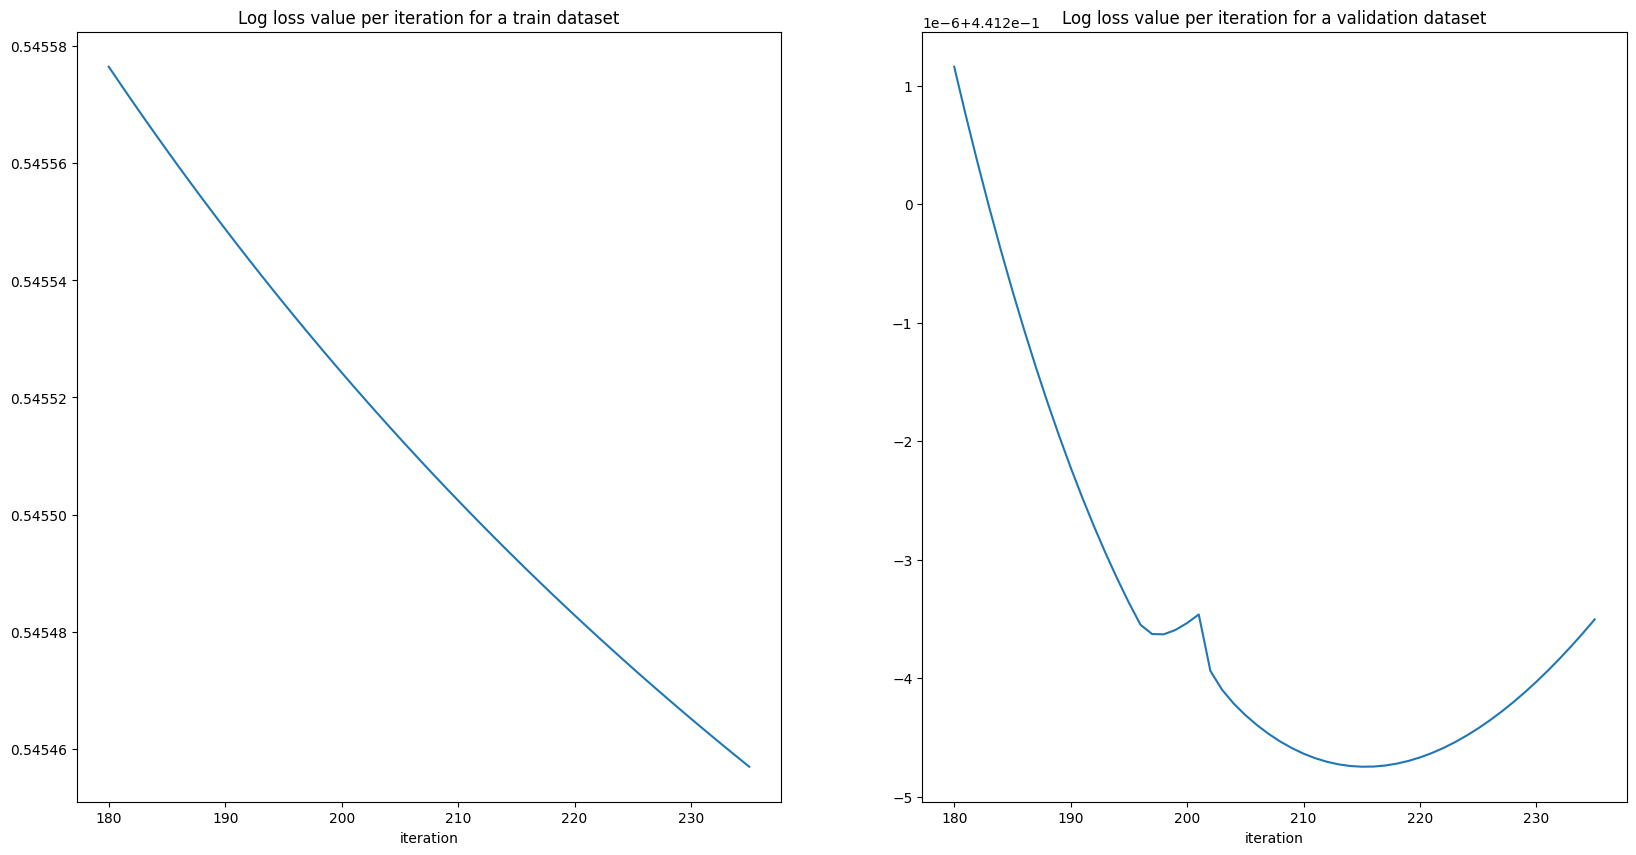

In [58]:
fig, axs = plt.subplots(ncols=2, nrows=1, figsize=(20, 10))
index = 0
axs = axs.flatten()
for col in ['new_train_log_loss', 'new_validation_log_loss']:
    ix = (full_res['iteration'] >= 180) & (full_res['iteration'] <= 240)
    axs[index].plot(full_res['iteration'].loc[ix], full_res[col].loc[ix])
    axs[index].set_xlabel('iteration')
    axs[index].set_ylabel(col_name_mapping.get(col))
    axs[index].set_title(titles.get(col))
    index += 1
# plt.tight_layout(pad=0.5, w_pad=0.5, h_pad=5.0)